## Goal
1. The USAE screwed up Softmax distributions. We will now verify if
- Single SAE SGen Score Happens
- Systematically, one by one, see if training a separate checkpoint leads to anything meaningful.

Setup

In [1]:
import os
import torch
import warnings
import torch.nn as nn
from tqdm import tqdm
from einops import rearrange
import matplotlib.pyplot as plt
from overcomplete.sae import TopKSAE
from domainbed.networks import Identity
from timm.layers import SelectAdaptivePool2d
from domainbed.algorithms import DANN, CORAL, Mixup, MMD, IRM, ERM, SagNet
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torch.nn.functional as F


from lib.parser import get_top_k_steps
from lib.loaders import load_backbone
from lib.data_handlers import  Load_PACS
from lib.analysis import ConceptAnalyzer
from lib.gpu_pacs import get_pacs_gpuloader, get_pacs_standard_loader
from lib.utils import extract_features



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
algo_classes = {"DANN": DANN, "CORAL": CORAL, "Mixup": Mixup, "MMD": MMD, "IRM": IRM, "ERM": ERM, "SagNet": SagNet}
warnings.filterwarnings("ignore", category=UserWarning)
torch.cuda.empty_cache()

c:\Users\sproj_ha\miniconda3\envs\interpretability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load the Models

In [2]:
model_dir = r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\PACS_ResNet_Sketch_Test_Only\ERM_ResNet_T3"
best_nonoracle_steps = get_top_k_steps(os.path.join(model_dir, "out.txt"), envs=[0, 1, 2], k=3)
best_oracle_steps = get_top_k_steps(os.path.join(model_dir, "out.txt"), envs=[0, 1, 2, 3], k=3)


print(f"Best Non-Oracle: {best_nonoracle_steps}")
print(f"Best Oracle: {best_oracle_steps}")

backbones = {}
for step in set(best_nonoracle_steps).union(set(best_oracle_steps)):
    backbones[step] = load_backbone("ERM_ResNet_T3", os.path.join(model_dir, f"model_step{step}.pkl"))

Best Non-Oracle: [3300, 2100, 1500]
Best Oracle: [2100, 4200, 3300]


In [3]:
class Normalizer(nn.Module): 
    def __init__(self, model, dataset, domains=None):
        super().__init__() 

        self.dataset = dataset
        if self.dataset == 'PACS':
            dl, _ = Load_PACS(domains=domains, batch_size=1024)
            x, _ = next(iter(dl))
            
            model.to(device)
            activations = extract_features(model, x.to(device))

        flat = activations.flatten()
        
        self.register_buffer('mean', flat.mean())
        self.register_buffer('std', flat.std())
                
    def forward(self, activations): 
        activations = (activations - self.mean)
        activations = activations / (self.std + 1e-12)
        return activations

    def denormalize(self, normalized_activations):
        return (normalized_activations * (self.std + 1e-12)) + self.mean

In [ ]:
domains = {
    0: "art_painting", 
    1: "cartoon",
    2: "photo",
    3: "sketch"
}

# TEST TO TRAIN ENVS
envs = {
    "T0": [1, 2, 3],
    "T1": [0, 2, 3],
    "T2": [0, 1, 3],
    "T3": [0, 1, 2],
    "T23": [0, 1], 
    "T13": [0, 2], 
    "T12": [0, 3], 
    "T03": [1, 2], 
    "T02": [1, 3], 
    "T01": [2, 3]
} 

def train_pacs_SAEs(backbone, save_path, name, rearrange_string='n t d -> (n t) d', 
                    nb_concepts=None, top_k=None, learning_rate=None, epochs=None, 
                    checkpoint_path=None, batch_size=64, full_data_gpu=False,
                    enable_logging=False, logging_dir=None, name_flag=None):
    """
    Train a Sparse Autoencoder on PACS data.
    
    Args:
        backbone: The neural network backbone
        save_path: Path where to save the trained SAE
        name: Model name for naming the SAE file
        rearrange_string: String for rearranging activations
        nb_concepts: Number of concepts (required if not using defaults)
        top_k: Top-k sparsity value (required if not using defaults)
        learning_rate: Learning rate for optimizer (defaults to 3e-4)
        epochs: Number of training epochs (defaults to 250)
        checkpoint_path: Path to checkpoint to resume training from
        batch_size: Batch size for training (defaults to 64)
        full_data_gpu: If True, load all data to GPU; if False, use standard CPU-based loader (defaults to False)
        enable_logging: If True, log loss to file and create loss curve (defaults to False)
        logging_dir: Directory to save logs and loss curve (required if enable_logging=True)
        name_flag: Optional flag to append to filename (e.g., 'SAE_ERM_ViT_T3_FLAG.pt' if name_flag='FLAG')
    """
    
    # Parse name to get train environments
    algo_name, backbone_name, test_envs = name.split("_")
    trainenvs = envs[test_envs]
    
    # Choose loader based on full_data_gpu flag
    if full_data_gpu:
        domain_train_loader = get_pacs_gpuloader(domains=[domains[e] for e in trainenvs], batch_size=batch_size, drop_last=True)
    else:
        domain_train_loader = get_pacs_standard_loader(domains=[domains[e] for e in trainenvs], batch_size=batch_size, drop_last=True)

    print(f"test envs: {test_envs}")
    print(f"train envs: {trainenvs}")
    
    # Validate SAE configuration
    if nb_concepts is None or top_k is None:
        raise ValueError(
            "SAE configuration (nb_concepts and top_k) must be explicitly provided via command-line arguments. "
            "No defaults are assumed. Use --nb-concepts and --top-k to specify values."
        )
    
    # Set defaults for learning rate and epochs if not provided
    if learning_rate is None:
        learning_rate = 3e-4
    if epochs is None:
        epochs = 250
    
    print(f"SAE Configuration: nb_concepts={nb_concepts}, top_k={top_k}")
    print(f"Training Configuration: lr={learning_rate}, epochs={epochs}")
    
    # Initialize or load SAE
    if checkpoint_path is not None:
        print(f"Loading SAE from checkpoint: {checkpoint_path}")
        sae = torch.load(checkpoint_path, weights_only=False)
        sae.train()
    else:
        fdim = nb_concepts // 8
        print(f"FDIM : {fdim}")
        sae = TopKSAE(fdim, nb_concepts=nb_concepts, top_k=top_k, device="cuda")
        sae.train()

    optimizer = torch.optim.Adam(sae.parameters(), lr=learning_rate)

    warmup_scheduler = LinearLR(optimizer, start_factor=1e-6 / learning_rate, end_factor=1.0, total_iters=10)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=epochs-25, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[25])
    
    criterion = nn.L1Loss(reduction="mean")  
    epoch_loss = 0.0

    if not hasattr(sae, "normalizer"):
        sae.normalizer = Normalizer(backbone, "PACS")
    backbone.to(device)
    
    # Validate logging configuration and load history if resuming
    loss_history = []
    starting_epoch = 0
    if enable_logging:
        if logging_dir is None:
            raise ValueError("logging_dir must be provided when enable_logging=True")
        os.makedirs(logging_dir, exist_ok=True)
        loss_log_file = os.path.join(logging_dir, f"loss_{algo_name}_{backbone_name}_{test_envs}" + (f"_{name_flag}" if name_flag else "") + ".txt")
        loss_curve_file = os.path.join(logging_dir, f"loss_curve_{algo_name}_{backbone_name}_{test_envs}" + (f"_{name_flag}" if name_flag else "") + ".png")
        
        # Load previous loss history if resuming from checkpoint
        if checkpoint_path is not None and os.path.exists(loss_log_file):
            print(f"Loading existing loss history from checkpoint resume...")
            with open(loss_log_file, 'r') as f:
                loss_lines = f.readlines()
            for line in loss_lines:
                try:
                    loss_value = float(line.split(': ')[-1].strip())
                    loss_history.append(loss_value)
                except:
                    pass
            starting_epoch = len(loss_history)
            print(f"Resumed from epoch {starting_epoch}. Will train for {epochs} more epochs.")
    else:
        loss_log_file = None
        loss_curve_file = None

    pbar = tqdm(range(epochs), desc=f"Training SAE: {name}")
    for epoch in pbar:
        actual_epoch_num = starting_epoch + epoch + 1  # For display (1-indexed)
        total_epochs = starting_epoch + epochs
        epoch_loss = 0.0
        for i, (images, _) in enumerate(domain_train_loader):
            
            activations = extract_features(backbone, images) # Forward Pass
            activations = sae.normalizer(activations) # Normalize
            activations = rearrange(activations, rearrange_string) # Rearrange

            optimizer.zero_grad()
            z_pre, z = sae.encode(activations)
            activations_hat = sae.decode(z)

            loss = criterion(activations_hat, activations)
            
            loss.backward()        
            optimizer.step()
            scheduler.step()
            
            epoch_loss += loss.item()
        
        # Average loss over batches
        avg_epoch_loss = epoch_loss / len(domain_train_loader)
        loss_history.append(avg_epoch_loss)
        
        # Update tqdm postfix to show loss
        if hasattr(epoch, '__len__'):
            pass  # In case tqdm object behaves differently
        
        # Log and update plot if logging is enabled
        if enable_logging:
            # Write to log file (appends to existing)
            with open(loss_log_file, 'a') as f:
                f.write(f"Epoch {actual_epoch_num}/{total_epochs}: {avg_epoch_loss:.6f}\n")
            
            # Update loss curve every 10 epochs or at the end
            if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
                plt.figure(figsize=(10, 6))
                plt.plot(loss_history, linewidth=2)
                plt.xlabel('Epoch')
                plt.ylabel('Loss')
                plt.title(f'Training Loss - {name}')
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(loss_curve_file, dpi=100)
                plt.close()
        
        # Update tqdm with loss info (always show, even without logging)
        pbar.set_postfix(loss=f"{avg_epoch_loss:.6f}")

    torch.save(sae, os.path.join(save_path, f"SAE_{algo_name}_{backbone_name}_{test_envs}" + (f"_{name_flag}" if name_flag else "") + ".pt"))
    print(f"SAE saved to {os.path.join(save_path, f'SAE_{algo_name}_{backbone_name}_{test_envs}' + (f'_{name_flag}' if name_flag else '') + '.pt')}")

In [5]:
train_pacs_SAEs(
    backbones[3300].to(device), 
    r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\SAEs\normalization_testing", 
    "ERM_ResNet_T3",
    nb_concepts=2048*8,
    top_k=16,
    learning_rate=3e-4,
    epochs=250,
    checkpoint_path=None,
    rearrange_string='n c w h -> (n w h) c',
    batch_size=64,
    full_data_gpu=True,
    enable_logging=True,
    logging_dir=r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\logs\normal_single_loaded",
    name_flag="normal_loaded_3300"
)

test envs: T3
train envs: [0, 1, 2]
SAE Configuration: nb_concepts=16384, top_k=16
Training Configuration: lr=0.0003, epochs=250
FDIM : 2048


Training SAE: ERM_ResNet_T3: 100%|██████████| 250/250 [19:19<00:00,  4.64s/it, epoch=250/250, loss=0.097753]


SAE saved to C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\SAEs\normalization_testing\SAE_ERM_ResNet_T3_normal_loaded_3300.pt


Train a single SAE on 3300

In [9]:
ckpt = 3300

SAEs = {}
SAEs[ckpt] = torch.load(r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\SAEs\normalization_testing\SAE_ERM_ResNet_T3_normal_loaded_3300.pt", weights_only=False).to(device)

Running Analysis

In [10]:
import math
import torch
from tqdm import tqdm
from einops import rearrange
from lib.data_handlers import Load_PACS
import json
import os
import json
from collections import defaultdict, Counter
from overcomplete.visualization.plot_utils import (interpolate_cv2, get_image_dimensions, show)
from overcomplete.visualization.cmaps import VIRIDIS_ALPHA


domains = ["photo", "art_painting", "cartoon", "sketch"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def calculate_mean_activations(backbone, sae, rearrange_string, w=14, domains=domains, nb_concepts=7680):
    activations = {}
    for cls in range(7):
        
        activations[cls] = {}
        z_d = torch.zeros((len(domains), nb_concepts)).to(device)
        
        for d, domain in enumerate(domains):
            loader, _ = Load_PACS(domains=[domain])
            for i, batch in enumerate(tqdm(loader)):
                with torch.no_grad():
                    img, y = batch
                    img, y = img.to(device), y.to(device)
                    
                    x = extract_features(backbone, img)
                    x = sae.normalizer(x)
                    x = rearrange(x, rearrange_string)

                    _, heatmaps = sae.encode(x)

                    mask = (y == cls).squeeze().to(device)  # (batch_size,)
                    heatmaps = rearrange(heatmaps, '(n w h) d -> n w h d', w=w, h=w)  # (n, t, d)
                    heatmaps_filtered = heatmaps[mask]  # (n_cls, t, d)
                    
                    z_d[d] += heatmaps_filtered.sum(dim=0).sum(dim=0).sum(dim=0)
                    

        activations[cls] = z_d
        
    return activations

def save_json(data, filepath):
    try:
        with open(filepath, 'w') as f:
            json.dump(data, f, indent=4)
        print(f"Successfully saved logs to {filepath}")
    except TypeError as e:
        print(f"Error saving JSON: {e}. Check for non-serializable types (like tensors).")
    except Exception as e:
        print(f"An error occurred: {e}")

def calculate_invariance(activations, ent_thresh=0.7, act_thresh=0, domains=domains, nb_concepts=7680):
    clss = 7
    logs = {
        "model_invariance" : 0,
        "final_invariance_per_class": {},
        "thresholded_concept_entropies": {}
    }
    for cls in range(clss):
        # mask = probabilities[cls] != 0.25
        processed = activations[cls] # * mask
        
        sum_entropy = 0.0
        class_concept_logs = []

        for i in range(nb_concepts):
            if processed[:, i].sum() == 0:
                continue

            score = processed[:, i] / processed[:, i].sum()

            entropy = -1 / torch.log(torch.tensor(len(domains))) * (score * torch.log(score + 1e-12)).sum()

            if entropy > ent_thresh and processed[:, i].sum() > act_thresh:
                sum_entropy += entropy

                # --- LOG INDIVIDUAL ENTROPY ---
                class_concept_logs.append({
                    "concept_index": i,
                    "entropy": entropy.item(),
                    "scores": [s.item() for s in score],
                    "mean_acts": [val.item() for val in processed[:, i]]
                })

        invariance_val = (sum_entropy)
        if isinstance(invariance_val, torch.Tensor):
            invariance_float = invariance_val.item()
        else:
            invariance_float = invariance_val # It might already be a float (if sum_entropy was 0.0)

        # --- LOG FINAL INVARIANCE ---
        logs["final_invariance_per_class"][cls] = invariance_float
        logs["model_invariance"] += invariance_float
        # --- LOG ALL CONCEPT ENTROPIES FOR THIS CLASS ---
        logs["thresholded_concept_entropies"][cls] = class_concept_logs

        print(f"Total Thresholded Entropy (INVARIANCE) for class {cls}: {invariance_float}")


    logs["model_invariance"] /= 7
    return logs



In [11]:
domains = ["art_painting", "cartoon", "photo"]

mean_acts = calculate_mean_activations(backbone=backbones[ckpt].to(device), sae=SAEs[ckpt], rearrange_string="n d w h -> (n w h) d", w=7, nb_concepts=2048*8, domains=domains)
logs = calculate_invariance(mean_acts, 0.0, 0, domains=domains, nb_concepts=2048*8)
save_json(logs, f"./invariances/INV_ERM_ResNet_T3_step{ckpt}_NORMALIZED.json")

100%|██████████| 20/20 [00:02<00:00,  7.02it/s]


Total Thresholded Entropy (INVARIANCE) for class 0: 462.92425537109375
Total Thresholded Entropy (INVARIANCE) for class 1: 344.93963623046875
Total Thresholded Entropy (INVARIANCE) for class 2: 356.53369140625
Total Thresholded Entropy (INVARIANCE) for class 3: 353.1496276855469
Total Thresholded Entropy (INVARIANCE) for class 4: 416.11126708984375
Total Thresholded Entropy (INVARIANCE) for class 5: 325.3384094238281
Total Thresholded Entropy (INVARIANCE) for class 6: 445.5444641113281
Successfully saved logs to ./invariances/INV_ERM_ResNet_T3_step3300_NORMALIZED.json


In [14]:
import json
from typing import Dict, Any
from collections import defaultdict, Counter

class ConceptAnalyzer:
    def __init__(self, filepath: str):
        """Loads the JSON data from the specified filepath."""
        self.filepath = filepath
        self.data = self._load_data()
        
    def _load_data(self) -> Dict[str, Any]:
        """Reads the JSON file and returns it as a dictionary."""
        try:
            with open(self.filepath, 'r') as file:
                return json.load(file)
        except FileNotFoundError:
            print(f"Error: The file {self.filepath} was not found.")
            return {}
        except json.JSONDecodeError:
            print(f"Error: The file {self.filepath} contains invalid JSON.")
            return {}
        
    def print_high_entropy_concepts(self, threshold: float, min_mean_acts_sum: float = 0.0):
        """
        Prints the concept indices and the total count of concepts 
        in each class that have an entropy strictly above the threshold K
        and a sum of mean_acts strictly above min_mean_acts_sum.
        """
        if not self.data:
            print("No data loaded. Cannot perform analysis.")
            return

        concept_data = self.data.get("thresholded_concept_entropies", {})
        
        if not concept_data:
            print("No 'thresholded_concept_entropies' found in the data.")
            return

        print(f"--- Concepts with Entropy > {threshold} & Sum(mean_acts) > {min_mean_acts_sum} ---")
        
        for class_id, concepts in concept_data.items():
            # Filter by both entropy threshold AND the sum of mean_acts
            valid_concepts = [
                c for c in concepts 
                if c.get("entropy", 0) > threshold and sum(c.get("mean_acts", [])) > min_mean_acts_sum
            ]
            
            concept_idxs = [c.get("concept_index") for c in valid_concepts]
            
            print(f"Class ID: {class_id}")
            print(f"  Total Concepts Above Thresholds: {len(concept_idxs)}")
            print(f"  Concept Indices: {concept_idxs}\n")

    def analyze_concept_occurrences(self, nb_concepts: int = 7680, min_strength: float = 0.0001):
        """
        Analyzes and prints how many classes each concept appears in,
        filtered by a minimum activation strength.
        """
        if not self.data:
            print("No data loaded. Cannot perform analysis.")
            return

        concept_data = self.data.get("thresholded_concept_entropies", {})
        if not concept_data:
            print("No 'thresholded_concept_entropies' found in the data.")
            return

        # Key = concept_index, Value = number of classes it appeared in
        concept_counts = defaultdict(int)

        # Iterate over all available class keys dynamically
        for class_key, items in concept_data.items():
            concepts_in_this_class = set()
            
            for item in items:
                idx = item.get('concept_index')
                # Safely get mean_acts; default to empty list if missing
                mean_acts = item.get('mean_acts', [])
                strength = sum(mean_acts)

                if idx is not None and strength > min_strength:
                    concepts_in_this_class.add(idx)
            
            # Update the global counter
            for idx in concepts_in_this_class:
                concept_counts[idx] += 1

        # Print detailed list (Concept vs Count)
        print(f"{'Concept Index':<15} | {'Class Count'}")
        print("-" * 30)
        
        found_concepts = sorted(concept_counts.keys())
        for idx in found_concepts:
            if 0 <= idx <= nb_concepts:
                print(f"{idx:<15} | {concept_counts[idx]}")

        # Calculate and Print Summary Statistics
        usage_frequency = Counter(concept_counts.values())

        print("\n" + "="*35)
        print("SUMMARY: FREQUENCY OF OCCURRENCES")
        print("="*35)
        
        # Iterate from 1 up to the total number of classes found in the JSON
        total_classes = len(concept_data)
        for i in range(1, total_classes + 1):
            count = usage_frequency.get(i, 0)
            print(f"Occurred exactly {i} time(s): {count} concept(s)")

In [22]:
analyzer = ConceptAnalyzer(f"./invariances/INV_ERM_ResNet_T3_step{ckpt}_NORMALIZED.json")
analyzer.print_high_entropy_concepts(threshold=0.9, min_mean_acts_sum=100000)

--- Concepts with Entropy > 0.9 & Sum(mean_acts) > 100000 ---
Class ID: 0
  Total Concepts Above Thresholds: 3
  Concept Indices: [2461, 3609, 4237]

Class ID: 1
  Total Concepts Above Thresholds: 5
  Concept Indices: [947, 2341, 3609, 4237, 8663]

Class ID: 2
  Total Concepts Above Thresholds: 6
  Concept Indices: [3609, 4237, 5937, 10209, 10271, 11934]

Class ID: 3
  Total Concepts Above Thresholds: 2
  Concept Indices: [6260, 11961]

Class ID: 4
  Total Concepts Above Thresholds: 3
  Concept Indices: [3609, 6296, 10050]

Class ID: 5
  Total Concepts Above Thresholds: 8
  Concept Indices: [1902, 2068, 3609, 4237, 7135, 9488, 11921, 13154]

Class ID: 6
  Total Concepts Above Thresholds: 4
  Concept Indices: [3609, 4237, 5768, 10271]



In [ ]:
import os
import torch
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
from einops import rearrange
import matplotlib.pyplot as plt
from torchvision import transforms
from lib.data_handlers import Load_PACS
from overcomplete.visualization.cmaps import VIRIDIS_ALPHA
from overcomplete.visualization.plot_utils import (interpolate_cv2, get_image_dimensions, show)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()

dirs = {
    "art_painting"  : r"C:\Users\sproj_ha\Desktop\DomainBed\domainbed\data\PACS\art_painting",
    "sketch"        : r"C:\Users\sproj_ha\Desktop\DomainBed\domainbed\data\PACS\sketch",
    "photo"         : r"C:\Users\sproj_ha\Desktop\DomainBed\domainbed\data\PACS\photo",
    "cartoon"       : r"C:\Users\sproj_ha\Desktop\DomainBed\domainbed\data\PACS\cartoon",
}

def visualize_class_on_concept(concept, class_idx, model, sae, rearrange_string, w=14, domain_roots=dirs, save_dir=None, n_images=None):
    
    domain_top_images = {}  # domain -> list of (heatmap_sum, img_tensor, heatmap)
    
    # 1. Build the global sorted class list EXACTLY like the dataloader
    all_classes = set()
    for d_path in domain_roots.values():
        for entry in os.scandir(d_path):
            if entry.is_dir():
                all_classes.add(entry.name)
    sorted_classes = sorted(list(all_classes))
    
    # 2. Map the index to the actual string name
    target_class_name = sorted_classes[class_idx]

    for domain, dir_path in domain_roots.items():
        # 3. Safely build the path using the string name
        class_dir = os.path.join(dir_path, target_class_name)
        
        if not os.path.exists(class_dir):
            continue
            
        images = [Image.open(os.path.join(class_dir, path)) for path in os.listdir(class_dir)]

        if n_images is not None and n_images < len(images):
            images = random.sample(images, n_images)

        results = []  # (heatmap_sum, img_tensor, heatmap)

        for i, img in enumerate(images):
            img = img.convert("RGB")
            transform = transforms.Compose([
                    transforms.Resize(256),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])
            ])

            img_tensor = transform(img).unsqueeze(dim=0).to(device) # Don't forget to send to device!

            x = extract_features(model, img_tensor)
            x = sae.normalizer(x)
            
            x = rearrange(x, rearrange_string)
            
            _, z = sae.encode(x)
            
            # FIX 2: Use dynamic spatial dimensions
            z = rearrange(z, '(n w h) d -> n w h d', w=w, h=w)
            
            width, height = img_tensor.shape[-1], img_tensor.shape[-2]
            
            # FIX 3: Isolate the specific 2D image, detach, move to CPU, and convert to numpy
            heatmap_2d = z[0, :, :, concept].detach().cpu().numpy()
            
            heatmap = interpolate_cv2(heatmap_2d, (width, height))
            heatmap_sum = heatmap.sum()

            if heatmap_sum > 0:
                results.append((heatmap_sum, img_tensor.cpu(), heatmap)) # Move img_tensor back to CPU for storage/plotting

        # Sort by activation and keep top 8
        results.sort(key=lambda x: x[0], reverse=True)
        domain_top_images[domain] = results[:8]

    # Build grid: rows = domains, cols = top-8 images
    domains = list(domain_top_images.keys())
    n_domains = len(domains)
    n_cols = 8

    fig, axes = plt.subplots(n_domains, n_cols, figsize=(n_cols * 2, n_domains * 2))

    # Ensure axes is always 2D
    if n_domains == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, domain in enumerate(domains):
        top = domain_top_images[domain]
        for col in range(n_cols):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(top):
                _, img_tensor, heatmap = top[col]
                # Convert image tensor to HWC numpy for display
                show(img_tensor, ax=ax)
                show(heatmap, ax=ax, cmap=VIRIDIS_ALPHA, alpha=1.0)
            if col == 0:
                ax.set_title(domain, fontsize=8, loc='left', pad=2)

    plt.suptitle(f"Class {target_class_name} — Concept {concept} | Top 8 Activations", fontsize=11, y=1.01)
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, f"Class{class_idx}_Concept{concept}_Grid.png"), bbox_inches="tight")
        plt.close()
    else:
        plt.show()

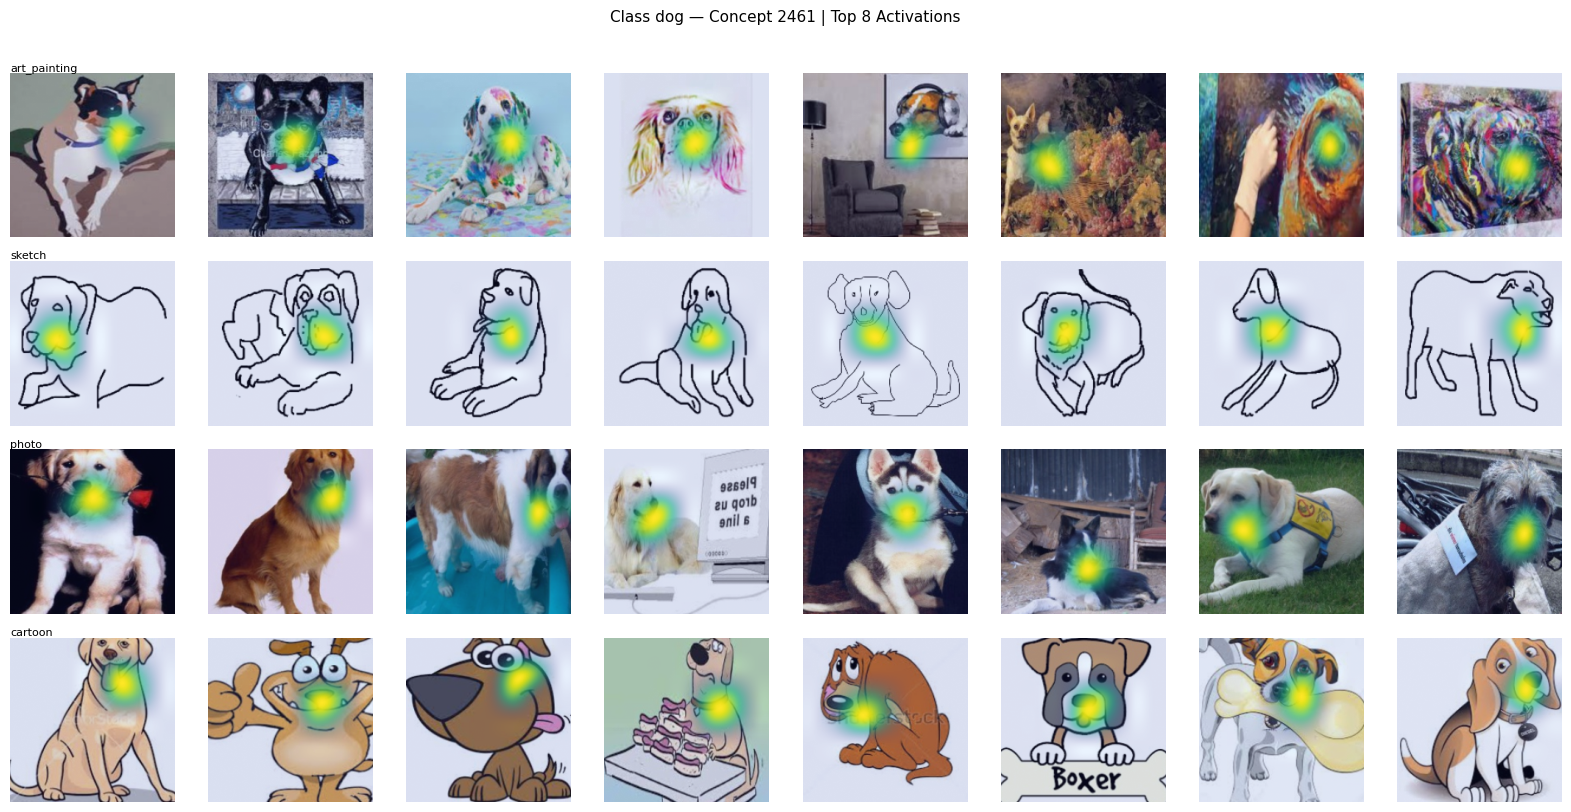

In [23]:
visualize_class_on_concept(2461, 0, backbones[ckpt].to(device), sae=SAEs[ckpt], rearrange_string='n c w h -> (n w h) c', w=7, save_dir=None, n_images=None, domain_roots=dirs) 

## Discrimination Score

Verify Accuracy of Reconstructed Latents

In [31]:
total_correct_std = 0
total_correct_sae = 0
total_samples = 0
results = {}

pool = SelectAdaptivePool2d(pool_type='avg', flatten=True)
softmax = nn.Softmax(dim=1)
domains = ["art_painting", "cartoon", "photo", "sketch"]

for domain in domains:
    loader, _ = Load_PACS(domains=[domain])
    
    # Domain-specific metrics tracking
    d_correct_std = 0
    d_correct_sae = 0
    d_samples = 0
    
    for i, batch in enumerate(tqdm(loader, desc=f"Evaluating {domain}")):
        x, y = batch
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            
            ## Classification
            z_raw = extract_features(backbones[ckpt], x)
            preds_std = backbones[ckpt].classifier(pool(z_raw))
            preds_std = preds_std.argmax(dim=1)
            
            
            # SAE Reconstruction Pipeline
            z_norm = SAEs[ckpt].normalizer(z_raw)
            n, c, h, w = z_norm.shape 
            z_flat = rearrange(z_norm, "n c h w -> (n h w) c")
            _, z_sae = SAEs[ckpt].encode(z_flat)
            z_recon_flat = SAEs[ckpt].decode(z_sae)
            z_recon = rearrange(z_recon_flat, '(n h w) c -> n c h w', n=n, h=h, w=w)
            z_recon = SAEs[ckpt].normalizer.denormalize(z_recon)
            
            # Predict using reconstructed latent
            preds_sae = backbones[ckpt].classifier(pool(z_recon))
            preds_sae = preds_sae.argmax(dim=1)

            
        # Update tallies
        d_correct_std += (preds_std == y).sum().item()
        d_correct_sae += (preds_sae == y).sum().item()
        d_samples += y.size(0)
    
    # Calculate domain accuracies
    acc_std = d_correct_std / d_samples
    acc_sae = d_correct_sae / d_samples
    degradation = acc_std - acc_sae
    
    # Store result for this domain specifically
    results[domain] = {
        'std': acc_std,
        'sae': acc_sae,
        'degradation': degradation
    }
    
    # Add to global tally
    total_correct_std += d_correct_std
    total_correct_sae += d_correct_sae
    total_samples += d_samples

# --- Final Results Formatting ---
print("\n" + "="*60)
print(f"{'Domain':<15} | {'Std Acc (%)':<12} | {'SAE Acc (%)':<12} | {'Degradation':<12}")
print("-" * 60)

for dom, metrics in results.items():
    std_pct = metrics['std'] * 100
    sae_pct = metrics['sae'] * 100
    deg_pct = metrics['degradation'] * 100
    print(f"{dom:<15} | {std_pct:>9.2f}%   | {sae_pct:>9.2f}%   | {deg_pct:>8.2f}%")

print("-" * 60)

# Calculate and print overall totals
overall_std = (total_correct_std / total_samples) * 100
overall_sae = (total_correct_sae / total_samples) * 100
overall_degradation = overall_std - overall_sae

print(f"{'OVERALL':<15} | {overall_std:>9.2f}%   | {overall_sae:>9.2f}%   | {overall_degradation:>8.2f}%")
print("="*60 + "\n")

Evaluating sketch: 100%|██████████| 49/49 [00:07<00:00,  6.85it/s]


Domain          | Std Acc (%)  | SAE Acc (%)  | Degradation 
------------------------------------------------------------
art_painting    |     99.00%   |     98.94%   |     0.06%
cartoon         |     98.06%   |     98.06%   |     0.00%
photo           |     99.61%   |     99.53%   |     0.08%
sketch          |     79.15%   |     79.69%   |    -0.54%
------------------------------------------------------------
OVERALL         |     90.97%   |     91.16%   |    -0.19%



### S_disc


In [35]:
def calculate_discrimination_scores(model, sae, dataloader, num_classes=7, nb_concepts=7680, device='cuda'):
    """
    ASSUMPTIONS:
    1. Score = P_unmasked(y_true) - P_masked(y_true).
       - Positive: Concept supports the ground truth.
       - Negative: Concept acted as a distractor/caused an error.
    2. Scores are only computed/aggregated for images where the concept's activation > 0.
    3. Aggregated over the entire dataset returning shape: (num_classes, nb_concepts).
    """
    model.eval()
    pool = SelectAdaptivePool2d(pool_type='avg', flatten=True)

    # Pre-allocate trackers on GPU
    accumulated_scores = torch.zeros((num_classes, nb_concepts), device=device)
    activation_counts = torch.zeros((num_classes, nb_concepts), device=device)
    
    for x, y in tqdm(dataloader, desc="Calculating Concept Discrimination"):
        x, y = x.to(device), y.to(device)
        n = x.size(0)
        
        with torch.no_grad():
            # --- Base Unmasked Pass ---
            z_raw = extract_features(model, x)
            z_norm = sae.normalizer(z_raw)
            _, _, h, w = z_norm.shape
            
            z_flat = rearrange(z_norm, "n c h w -> (n h w) c")
            _, z_sae = sae.encode(z_flat)
            
            z_recon_flat = sae.decode(z_sae)
            z_recon = rearrange(z_recon_flat, '(n h w) c -> n c h w', n=n, h=h, w=w)
            z_recon = sae.normalizer.denormalize(z_recon)
            
            logits_unmasked = model.classifier(pool(z_recon))
            probs_unmasked = F.softmax(logits_unmasked, dim=1)
            p_true_unmasked = probs_unmasked[torch.arange(n), y] 
            
            # --- Fast Masking Setup ---
            z_sae_img = rearrange(z_sae, '(n h w) c -> n (h w) c', n=n, h=h, w=w)
            concept_max_per_img, _ = z_sae_img.max(dim=1) # Shape: (n, nb_concepts)
            
            # Find concepts active at least once in the batch
            active_concepts_batch = torch.where(concept_max_per_img.max(dim=0)[0] > 0)[0]
            
            for c in active_concepts_batch:
                active_img_mask = concept_max_per_img[:, c] > 0
                
                if not active_img_mask.any():
                    continue
                    
                # OPTIMIZATION 1: In-place masking to save memory
                original_col = z_sae[:, c].clone()
                z_sae[:, c] = 0 
                
                # Forward pass with the single masked concept
                z_recon_flat_m = sae.decode(z_sae) # z_sae is currently masked
                z_recon_m = rearrange(z_recon_flat_m, '(n h w) c -> n c h w', n=n, h=h, w=w)
                z_recon_m = sae.normalizer.denormalize(z_recon_m)
                
                logits_masked = model.classifier(pool(z_recon_m))
                probs_masked = F.softmax(logits_masked, dim=1)
                p_true_masked = probs_masked[torch.arange(n), y]
                
                # Restore the original concept activations for the next loop iteration
                z_sae[:, c] = original_col
                
                # Calculate drop
                score_drop = p_true_unmasked - p_true_masked 
                
                # Filter to active images
                active_classes = y[active_img_mask]
                active_drops = score_drop[active_img_mask]
                
                # OPTIMIZATION 2: Vectorized GPU accumulation (No CPU sync)
                accumulated_scores[:, c].scatter_add_(0, active_classes, active_drops)
                activation_counts[:, c].scatter_add_(0, active_classes, torch.ones_like(active_drops))

    # Average the scores (clamp denominator to prevent div by zero)
    final_discrimination_scores = accumulated_scores / activation_counts.clamp(min=1)
    
    return final_discrimination_scores, activation_counts

In [37]:
loader, _ = Load_PACS(domains=domains)

scores, counts = calculate_discrimination_scores(
    model=backbones[ckpt],
    sae=SAEs[ckpt],
    dataloader=loader,
    num_classes=7,
    nb_concepts=2048 * 8,
    device=device
)

# 3. Print the most discriminative concepts per class in order of magnitude
top_k = 15  

print("\n" + "="*60)
print(f"MOST DISCRIMINATIVE CONCEPTS PER CLASS (TOP {top_k})")
print("="*60)

for cls_idx in range(7):
    class_scores = scores[cls_idx]
    class_counts = counts[cls_idx]
    
    # Sort indices by score magnitude (descending)
    sorted_indices = torch.argsort(class_scores, descending=True)
    
    print(f"\nClass {cls_idx}:")
    print(f"{'Concept ID':<15} | {'Disc. Score (Drop)':<20} | {'Act. Count':<15}")
    print("-" * 60)
    
    for i in range(top_k):
        c_idx = sorted_indices[i].item()
        score = class_scores[c_idx].item()
        count = class_counts[c_idx].item()
        
        # Skip printing if the concept never activated for this class
        if count == 0:
            continue
            
        print(f"{c_idx:<15} | {score:<20.4f} | {int(count):<15}")

print("\n" + "="*60)

Calculating Concept Discrimination: 100%|██████████| 124/124 [08:19<00:00,  4.03s/it]


MOST DISCRIMINATIVE CONCEPTS PER CLASS (TOP 15)

Class 0:
Concept ID      | Disc. Score (Drop)   | Act. Count     
------------------------------------------------------------
2461            | 0.2697               | 1315           
5781            | 0.0190               | 1233           
387             | 0.0146               | 793            
10505           | 0.0136               | 1206           
15705           | 0.0127               | 945            
14550           | 0.0112               | 1233           
10078           | 0.0104               | 329            
15791           | 0.0097               | 877            
15962           | 0.0065               | 905            
3506            | 0.0063               | 777            
5223            | 0.0055               | 1124           
1853            | 0.0053               | 881            
3763            | 0.0048               | 953            
2502            | 0.0047               | 372            
9643            | 0.0047 

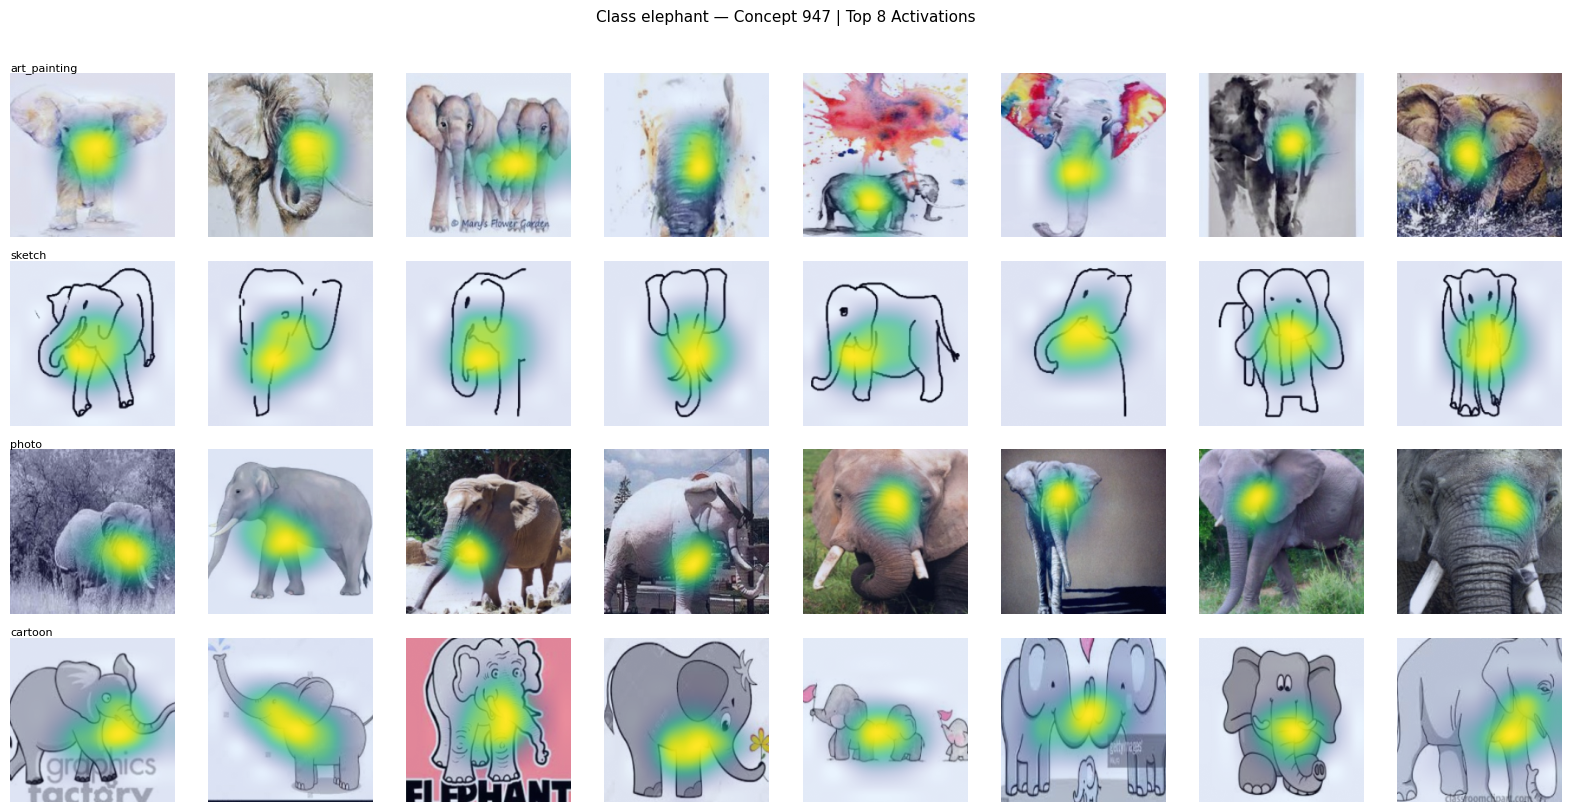

In [39]:
visualize_class_on_concept(947, 1, backbones[ckpt].to(device), sae=SAEs[ckpt], rearrange_string='n c w h -> (n w h) c', w=7, save_dir=None, n_images=None, domain_roots=dirs) 

In [72]:
import json

def combine_scores_to_json(existing_json_path, output_json_path, scores, counts):
    """
    Loads the existing invariance JSON, injects discrimination scores 
    AND activation counts for each concept, and saves the combined data.
    """
    try:
        with open(existing_json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error loading JSON: {e}")
        return

    concept_data = data.get("thresholded_concept_entropies", {})

    for class_id_str, concepts in concept_data.items():
        class_id = int(class_id_str)
        
        for concept in concepts:
            c_idx = concept.get("concept_index")
            
            # Check if concept index is valid and it actually fired
            if c_idx is not None and counts[class_id, c_idx] > 0:
                disc_score = float(scores[class_id, c_idx].item())
                act_count = int(counts[class_id, c_idx].item())
                
                concept["discrimination_score"] = disc_score
                concept["activation_count"] = act_count
            else:
                # Default to 0 if it never activated
                concept["discrimination_score"] = 0.0 
                concept["activation_count"] = 0

    with open(output_json_path, 'w') as f:
        json.dump(data, f, indent=4)
        
    print(f"Successfully created combined JSON at: {output_json_path}")
import json
import matplotlib.pyplot as plt

def plot_concept_quality(combined_json_filepath, class_to_plot=None, min_occurrences=0):
    """
    Reads the combined JSON and plots Discrimination (X) vs. Invariance/Entropy (Y).
    If class_to_plot is provided, it only plots that specific class.
    Only plots concepts that fired in at least `min_occurrences` images.
    X-axis is fixed to [-1, 1] and Y-axis is fixed to [0, 1].
    """
    try:
        with open(combined_json_filepath, 'r') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error loading Combined JSON: {e}")
        return

    concept_data = data.get("thresholded_concept_entropies", {})

    plt.figure(figsize=(12, 8))
    colors = plt.cm.tab10.colors  

    if class_to_plot is not None:
        class_to_plot = str(class_to_plot)

    for class_id_str, concepts in concept_data.items():
        if class_to_plot is not None and class_id_str != class_to_plot:
            continue

        x_vals = [] 
        y_vals = [] 
        
        for concept in concepts:
            entropy = concept.get("entropy")
            disc_score = concept.get("discrimination_score")
            act_count = concept.get("activation_count", 0) # Safely default to 0 if missing

            # Check metrics AND that it meets the minimum occurrence threshold
            if (entropy is not None and 
                disc_score is not None and 
                disc_score != 0.0 and 
                act_count >= min_occurrences):
                
                x_vals.append(disc_score)
                y_vals.append(entropy)

        if x_vals and y_vals:
            plt.scatter(
                x_vals, 
                y_vals, 
                label=f"Class {class_id_str}", 
                color=colors[int(class_id_str) % len(colors)], 
                alpha=0.7,
                edgecolors='w',
                linewidth=0.5
            )

    title_suffix = f" (Class {class_to_plot})" if class_to_plot is not None else " (All Classes)"
    filter_suffix = f" | Min Occurrences: {min_occurrences}" if min_occurrences > 0 else ""
    plt.title(f"Discrimination vs. Invariance{title_suffix}{filter_suffix}", fontsize=16, fontweight='bold')
    
    plt.xlabel("Discrimination Score (Drop in Ground Truth Confidence)", fontsize=12)
    plt.ylabel("Invariance Score (Entropy across Domains)", fontsize=12)
    
    plt.xlim(-1, 1)
    plt.ylim(0, 1)
    
    plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    
    if plt.gca().get_legend_handles_labels()[0]:
        plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

In [44]:
# 1. Combine and save your data
combine_scores_to_json(
    existing_json_path=r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\invariances\INV_ERM_ResNet_T3_step3300_NORMALIZED.json", 
    output_json_path=r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\invariances\GEN_ERM_ResNet_T3_step3300_NORMALIZED.json", 
    scores=scores, 
    counts=counts
)

Successfully created combined JSON at: C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\invariances\GEN_ERM_ResNet_T3_step3300_NORMALIZED.json


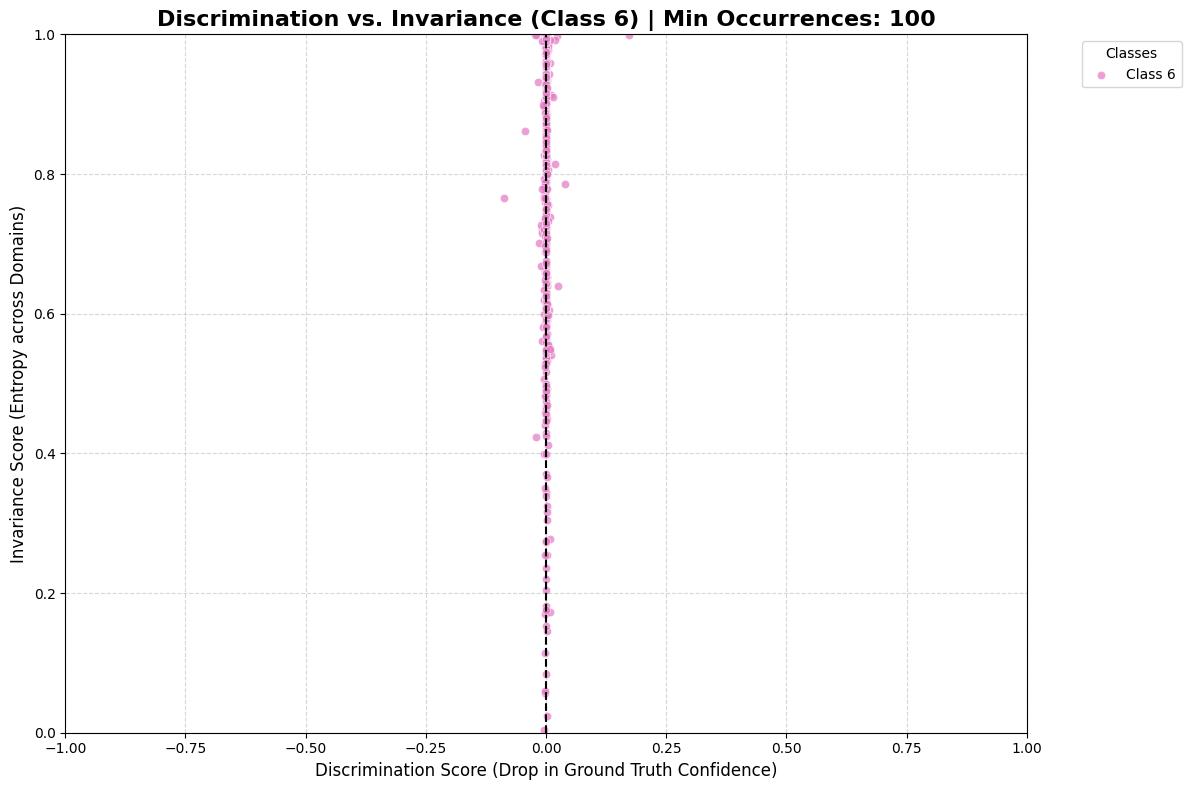

In [76]:
# 2. Plot from the single file
plot_concept_quality(r"C:\Users\sproj_ha\Desktop\SGen_Vision_Interp\Vision_Interp\invariances\GEN_ERM_ResNet_T3_step3300_NORMALIZED.json", class_to_plot=6, min_occurrences=100)